### Cleaner notes showing how to resolve the Kolmogorov Length Scale

$\lambda_k = (\frac{\nu^3}{\varepsilon})^{1/4}$ and komogorov length scale is resolved if: $ \lambda_k > \Delta x, \Delta y, \Delta z $

Paperella and Young (2003) have a theoretical constraint on $ \varepsilon = < \kappa H^{-1} b_{max} $

Our goal in this notebook is to make sure that the kolmogorov scale is resolved for higher Rayleigh numbers, in this example $Ra = 1e8$. 

A topographically-constrained buoyancy-driven horizontal convection simulation is run to equilibrium (7000 nondimensional timesteps) for $Ra=1e8$. The test resolution is Nx=256, Ny=1, Nz=32. So the aspect ratio is 8. 

The goal is to first check if the kolmogorov scale is resolved. If it is not, we want to find the optimal resolution. 


In [2]:
#first import our packages

#using Oceananigans
using NCDatasets
using Printf
using CairoMakie
using Oceananigans.Fields
using Oceananigans.Abstractn Operations: volume
using NaNStatistics

LoadError: UndefVarError: `Abstractn` not defined

In [2]:
using TopographicHorizontalConvection
using TopographicHorizontalConvection: HorizontalConvectionSimulation

Precompiling TopographicHorizontalConvection
  ✓ NaNStatistics
  ✓ Oceanostics
  ✓ TopographicHorizontalConvection
  3 dependencies successfully precompiled in 22 seconds. 335 already precompiled.


In [3]:
#this data is from my local laptop repo, I uploaded it to HPC3 so I could create the notebook here. 
#note this is oceanostics data, which includes the online calculations of epsilon, ke, and chi

ds = NCDataset("/pub/ikeshwan/code/HorizontalConvection/output/Ra1e8Kolmogorov/turbulent_h0.6_Ra1.0e8_coldstart_oceanostics.nc");

To calculate the kolmogorov length scale $ \lambda_k $ we need $ \epsilon $ there are two ways of finding $\epsilon$. One is the online calculation from the simulation data, and the other is the theoretical calculation from Paperella and Young. We can compare the two.

### Let's start by analyzing the online calculation of epsilon from simulation data using the equation: 
$\lambda_k = (\frac{\nu^3}{\varepsilon})^{1/4}$

We know $\varepsilon$ from simulation data and can solve for $\nu$ using the formula: $\nu = \sqrt\frac{Pr b_* H^3}{Ra}$, where Pr is Prandlt Number, $b_*$ is the value of initial buoyancy forcing, H is the vertical height of the domain, and Ra is the Rayleigh number

Note: this is an older dataset before I had global variables assigned, so I am retreiving the variables such as Prandlt number, b*, H from the simulation file. But for newer datasets I have all these variables assigned as global variables so they can be retrieved directly from the file. Rayleigh number example shown below (the only global variable I have assigned on this older dataset!

In [4]:
Ra = ds.attrib["Ra"]

1.0e8

In [5]:
ε_sim = ds["ε"][4+1:end-4, 1, 4+1:end-4, :];

Pr = 1.0;
b★ = 1.0;
H = 1.0;
#Ra defined above

#calculate ν

ν = sqrt(Pr * b★ * H^3 / Ra);


In [6]:
size(ε_sim)

(256, 32, 701)

Let's create a heatmap of $\varepsilon$ at some time closer to equilibrium. 

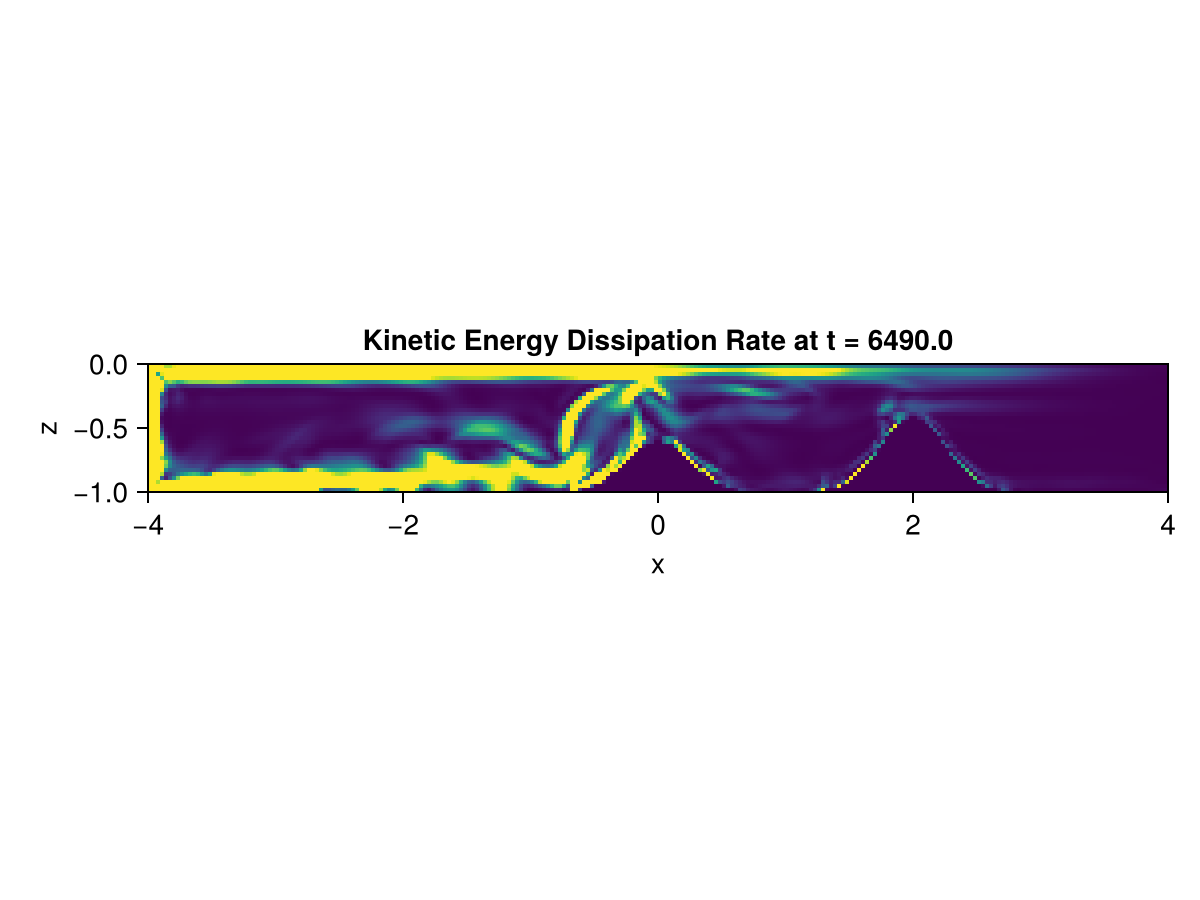

In [7]:
x = ds["xC"][4+1:end-4]; #taking the center of the vertical grid cells removing the halos
z = ds["zC"][4+1:end-4];
time = ds["time"][:];

f = Figure()
ax = Axis(f[1,1], aspect=8, xlabel="x", ylabel="z", title="Kinetic Energy Dissipation Rate at t = 6490.0")
heatmap!(ax, x, z, ε_sim[:, :, 650], colormap=:viridis, colorrange=(0,0.0001))

f

Cool! This shows how the kinetic energy dissipation is much higher around the sills.

In [8]:

# Currently the size of epsilon is (Nx, Nz, length(time))
print(size(ε_sim))

# z is defined above when creating the heatmap
Nz = length(z);
Δz = reshape(diff(ds["zF"])[4+1:end-4], 1, 1, Nz);

println(size(Δz))

(256, 32, 701)(1, 1, 32)


Now we're ready to implement the kolomogorov length scale equation

In [9]:
#lets define a function to do this calculation

function get_λk(ν, ε)
    return (ν^3 ./ ε).^(0.25)
end

get_λk (generic function with 1 method)

In [10]:
#kolmogorov length scale for simulation epsilon:

λk_sim = get_λk(ν, ε_sim);
println(size(λk_sim)) #has dimensions Nx,Nz,length(time)

(256, 32, 701)


#### Now lets find out if the kolmogorov length scale is resolved using the $ \varepsilon $ from sim data

In [11]:
for n in 1:length(time)
    if all(Δz[1] .< λk_sim[:,:,n])
        println("Kolmogorov length scale is resolved")
    else
        #println("Kolmogorov length scale is not resolved")
    end
end

Kolmogorov length scale is resolved


#### Okay, this shows that the kolmogorov length scale is ONLY resolved for the first timestep, nowhere else!!

### Okay, now we should check if the kolmogorov length scale is also resolved using the theoretical constraint on epsilon. 

I have derived this in my notes: summer research notes 8/20/24: ** write these up! **

$ \varepsilon = < \kappa H^{-1} (max(b_0) - min(b_0) )$

in my setup, the maximum $b_0 = b_*$ and the minimum $b_0 = -b_*$

therefore, $ \varepsilon = <\frac{\kappa}{H} 2 b_*$

In [12]:
#again we should be using the global attributes to retrieve variables like κ, but this is an older dataset

κ = ν * Pr # this is defined in the simulation.jl code

ε_theoretical = κ * H^(-1) * 2 * b★;

λk_theoretical = get_λk(ν, ε_theoretical);

#now let's check whether or not theoretical epsilon is resolved

if Δz[1] < λk_theoretical
    println("Kolmogorov length scale is resolved")
else 
    println("Kolmogorov length scale is not resolved")
end


Kolmogorov length scale is not resolved


#### Okay, we now know we need to change the resolution to resolve the theoretical length scale. 

Let's plot the simulation epsilon and theoretical to compare them

In [23]:
#ok this is so shitty of me but seems like i never defined ε_sim_avg ???? 

function global_volume_integral(ds, var)
    x = ds["xC"][4+1:end-4]; Nx = length(x);
    z = ds["zC"][4+1:end-4]; Nz = length(z);
    time = ds["time"][:];
    Δx = reshape(diff(ds["xF"])[4+1:end-4], Nx,1,1);
    Δz = reshape(diff(ds["zF"])[4+1:end-4], 1,1,Nz);
    ΔA = Δx; #flat in y -- 2 dimensional
    ΔV = ΔA.*Δz;
    var_array = zeros(size(time,1));
    for n in 1:size(time, 1)
        var_t = ds[var][4+1:end-4, 1, 4+1:end-4, n]
        #wet = var_t.!=0.
        #var_t[.!wet] .= NaN
        var_array[n] = sum(
            var_t .*
            ΔV,
            dims=(1,2,3)
        )[1,1,1]
    end  
    return var_array
end

ε_sim_int = global_volume_integral(ds, "ε");
ε_sim_avg = ε_sim_int / 8 ;

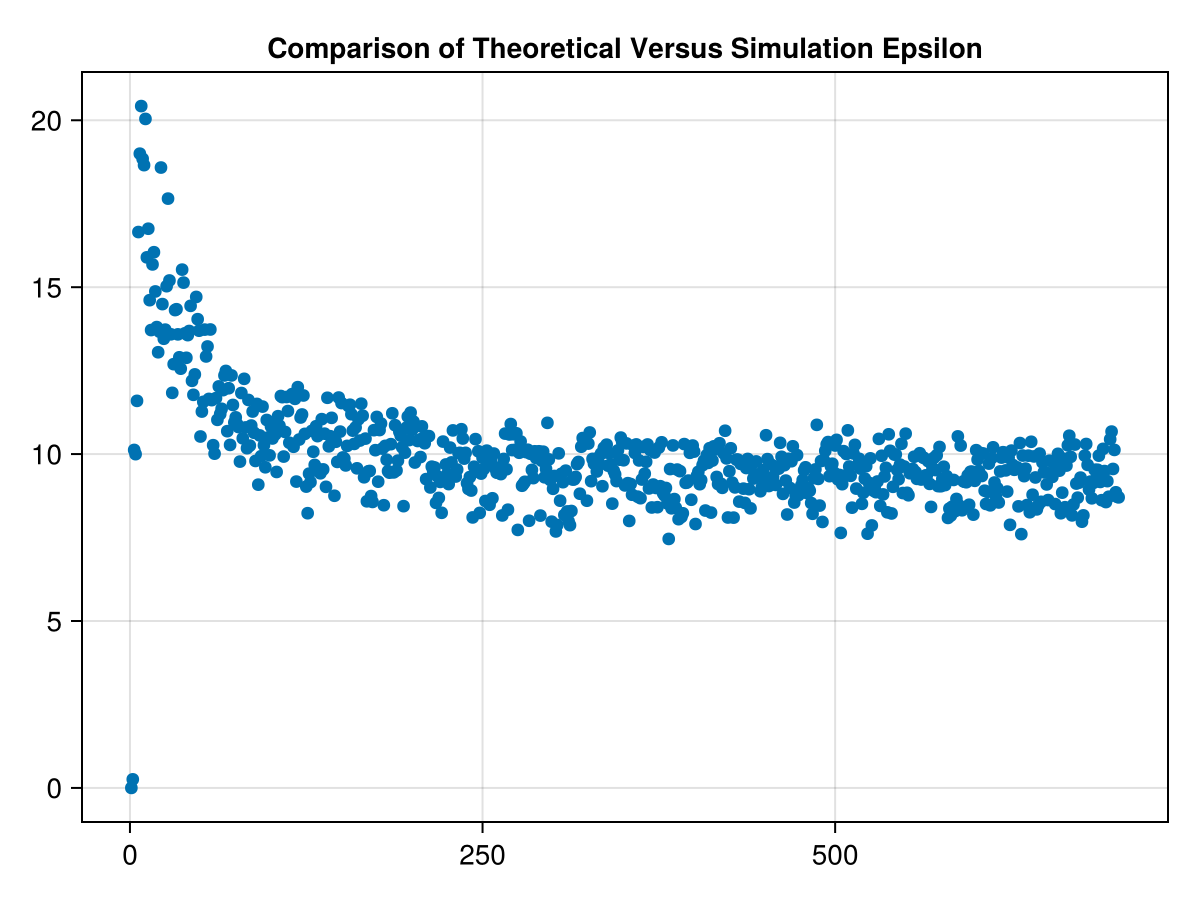

In [24]:
f2 = Figure()
ax = Axis(f2[1,1], title="Comparison of Theoretical Versus Simulation Epsilon")
plot!(ε_sim_avg/ε_theoretical)

f2

This plot shows that the simulation epsilon and theoretical epsilon do in fact converge to a comparable value over the course of the simulation. So, we should calculate a new resolution for the sim that fits the theoretical kolmogorov length scale

In [46]:
#curious to see how different the values are

Δz[1], λk_theoretical

#I will guess that the new Δz is equal to the theoretical kolmogorov scale to find the new Nx and Nz

Δz_guess = λk_theoretical;

To solve for the new resolution: Nx and Nz we can use the following relationships:

$ \Delta z = \frac{H}{N_z} \rightarrow N_z = \frac{H}{\Delta z} $

and $ N_x = \frac{N_x}{\Delta x} $

In [26]:
#our aspect ratio for our simulation is 8: we want to keep this consistent

Lx = 8H;
Nx_guess = Lx / Δz_guess;
Nz_guess = H / Δz_guess; 

In [27]:
print("Therefore the new resolution for Ra=1e8 is: Nx: ", round(Nx_guess), " and Nz: ", round(Nz_guess))

Therefore the new resolution for Ra=1e8 is: Nx: 951.0 and Nz: 119.0

In [28]:
close(ds)

closed Dataset

## Cool!

This is how I chose the new resolutions in the later simulations that would resolve the Kolmogorov Scales for the Ra=1e8 simulations. This can be repeated for higher Rayleigh numbers

## Now, let's check the newer sims with the updated resolutions and make sure the Kolmogorov Scales are actually resolved

we want to plot a snapshot or time-average at equilibrium of the ratios ε/ε_upper_bound and λk_sim/Δz

In [29]:
ds_new = NCDataset("/pub/ikeshwan/code/HorizontalConvection/output/turbulent_h0.6_Ra1.0e8_coldstart_oceanostics.nc");

In [30]:
#start by importing all important data

x_new = ds_new["xC"][4+1:end-4];
z_new = ds_new["zC"][4+1:end-4]; Nz_new = length(z_new)

ε_newsim = ds_new["ε"][4+1:end-4, 1, 4+1:end-4, :];

Ra = ds_new.attrib["Ra"];
b★ = ds_new.attrib["b★"];
κ = ds_new.attrib["κ"];
Pr = ds_new.attrib["Pr"];
H = ds_new.attrib["H"];
Lx = ds_new.attrib["Lx"];

In [31]:
#calculate ν

ν_new = sqrt(Pr * b★ * H^3 / Ra);

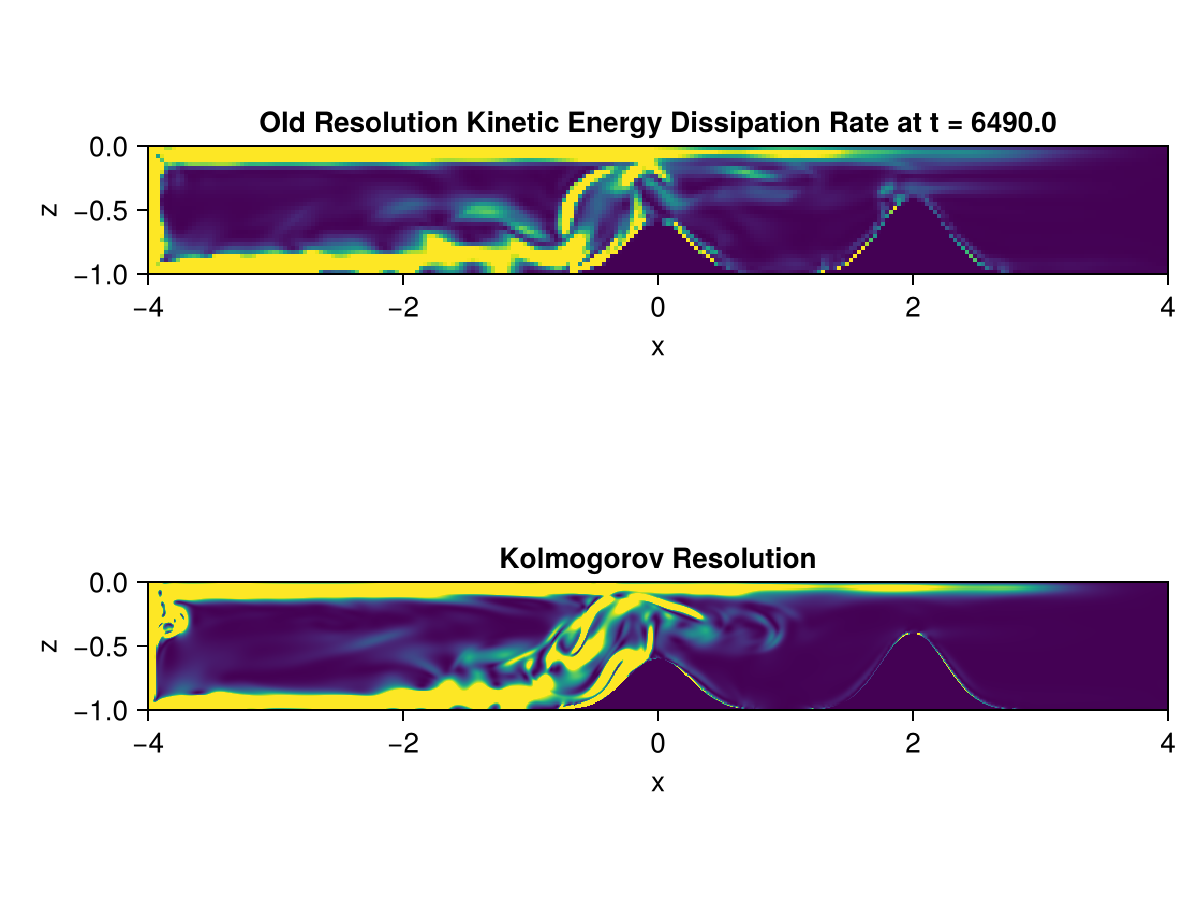

In [32]:
time = ds_new["time"][:];

fcompare_epsilon = Figure()
ax1 = Axis(fcompare_epsilon[1,1], aspect=8, xlabel="x", ylabel="z", title="Old Resolution Kinetic Energy Dissipation Rate at t = 6490.0")
ax2 = Axis(fcompare_epsilon[2,1], aspect=8, xlabel="x", ylabel="z", title="Kolmogorov Resolution")
heatmap!(ax1, x, z, ε_sim[:,:,650], colormap=:viridis, colorrange=(0,0.0001))
heatmap!(ax2, x_new, z_new, ε_newsim[:, :, 650], colormap=:viridis, colorrange=(0,0.0001))

fcompare_epsilon

The second panel, KE dissipation rate with the new resolution does visually look smoother

In [39]:
#lets see how the kolmogorov resolved ε compares to ε_theoretical

ε_new_int = global_volume_integral(ds_new, "ε");
ε_new_avg = ε_new_int / 8 ;

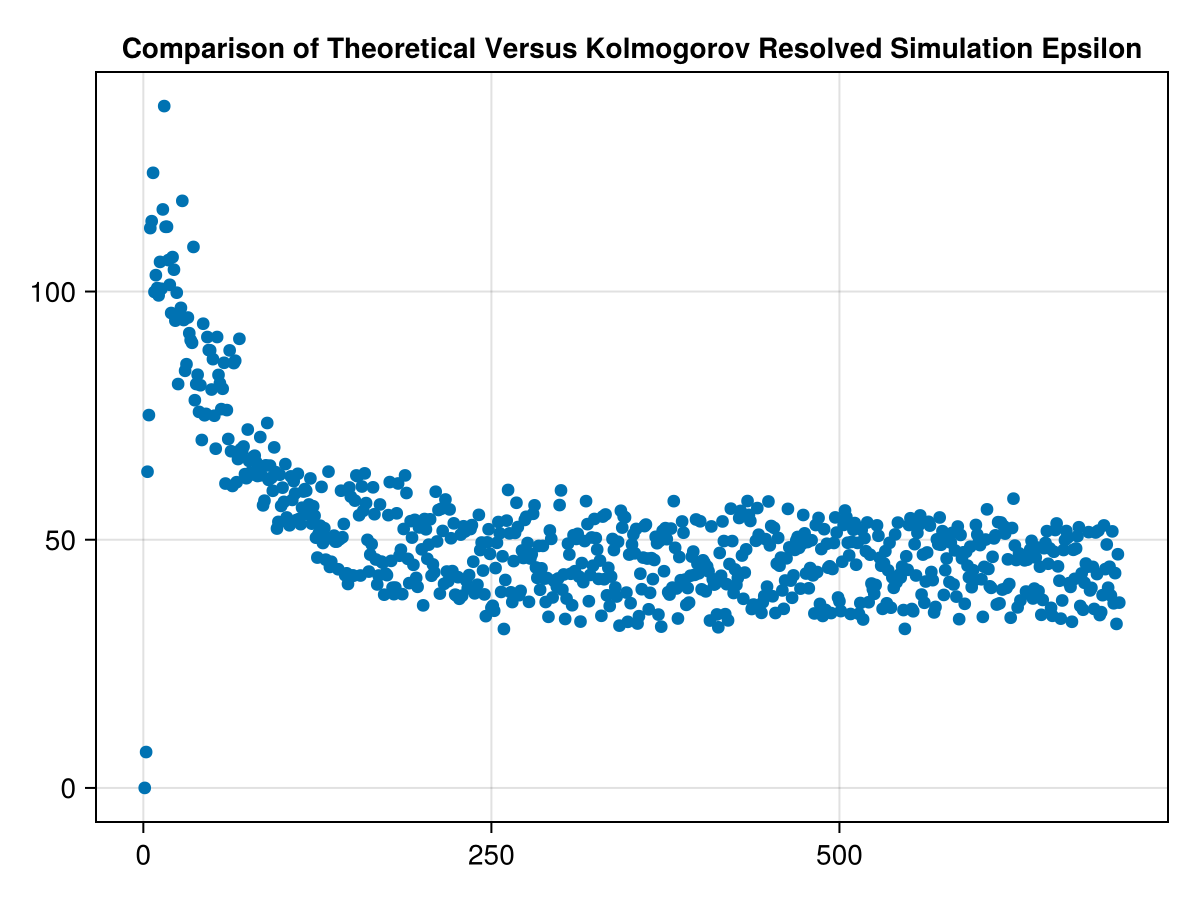

In [41]:
f4 = Figure()
ax = Axis(f4[1,1], title="Comparison of Theoretical Versus Kolmogorov Resolved Simulation Epsilon")
plot!(ε_new_avg/ε_theoretical)

f4

okay, so in the kolmogorov simulations, $\varepsilon$ is like five times larger. i'm not sure if this makes sense or not....

In [33]:
λk_newsim = get_λk(ν_new, ε_newsim);
Δz_new = reshape(diff(ds_new["zF"])[4+1:end-4], 1, 1, Nz_new);

In [34]:
λk_newsim_EQ = λk_newsim[:,:,701];

In [44]:
f4 = Figure()
ax = Axis(f4[1,1], title="Ratio λk/Δz")
heatmap!(x, z, λk_newsim_EQ./Δz_new)#plug in delta z here, colorrange=(0,0.001))

f4

LoadError: ArgumentError:     Conversion failed for Heatmap (With conversion trait CellGrid()) with args: Tuple{Vector{Float64}, Vector{Float64}, Array{Float64, 3}} .
    Heatmap requires to convert to argument types Tuple{AbstractVector{T} where T<:Real, AbstractVector{T} where T<:Real, AbstractMatrix{<:Union{Float32, Float64, ColorTypes.Colorant}}}, which convert_arguments didn't succeed in.
    To fix this overload convert_arguments(P, args...) for Heatmap or CellGrid() and return an object of type Tuple{AbstractVector{T} where T<:Real, AbstractVector{T} where T<:Real, AbstractMatrix{<:Union{Float32, Float64, ColorTypes.Colorant}}}.`
